In [1]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

from apartmentprices.eda import check_location_of_coordinates, check_near_duplicates
from apartmentprices.data import split_data
from apartmentprices.notebook_setup import setup
from apartmentprices.paths import RAW_DATA
from apartmentprices.visualization import (
    barplot,
    boxplot,
    distribution,
    mapplot,
    scatterplot,
    heatmap,
)

setup()

In [2]:
df = pd.read_csv(RAW_DATA / "data.csv")

df.head()

area      location   price       id  floor  floors  hasMortgage  \
0 170.0000000         Sahil  470000  6054458      4       4        False   
1 131.0000000        28 May  470000  5848015     10      17        False   
2 200.0000000  Həzi Aslanov  470000  5942677      4      15         True   
3 200.0000000  Həzi Aslanov  470000  5735140      4      17        False   
4 200.0000000  Həzi Aslanov  470000  5943238      4      15         True   

   rooms  hasBillOfSale hasRepair                  updatedAt        lat  \
0      4           True      True  2026-08-10T17:41:26+04:00 40.3705049   
1      3           True      True  2026-08-11T16:53:31+04:00 40.3833449   
2      4           True      True  2026-08-16T20:53:17+04:00 40.3783052   
3      4           True      True  2026-08-24T16:48:10+04:00 40.3784834   
4      4           True      True  2026-08-10T13:29:55+04:00 40.3781984   

         lng  
0 49.8446644  
1 49.8490615  
2 49.9595575  
3 49.9546431  
4 49.9597366

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52469 entries, 0 to 52468
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           52469 non-null  float64
 1   location       52469 non-null  str    
 2   price          52469 non-null  int64  
 3   id             52469 non-null  int64  
 4   floor          52469 non-null  int64  
 5   floors         52469 non-null  int64  
 6   hasMortgage    52469 non-null  bool   
 7   rooms          52469 non-null  int64  
 8   hasBillOfSale  52469 non-null  bool   
 9   hasRepair      52267 non-null  object 
 10  updatedAt      52469 non-null  str    
 11  lat            52469 non-null  float64
 12  lng            52469 non-null  float64
dtypes: bool(2), float64(3), int64(5), object(1), str(2)
memory usage: 6.3+ MB


In [4]:
df.describe()

area            price              id         floor  \
count 52469.0000000    52469.0000000   52469.0000000 52469.0000000   
mean     97.9945009   292857.8785569 6219250.9700395     7.3996836   
std      55.4141261   226129.7951616  302542.5915155     4.7435556   
min      11.0000000      600.0000000 1861228.0000000     1.0000000   
25%      64.5000000   170000.0000000 6183582.0000000     4.0000000   
50%      85.0000000   238000.0000000 6335209.0000000     6.0000000   
75%     120.0000000   340000.0000000 6376556.0000000    11.0000000   
max    1800.0000000 10000000.0000000 6415071.0000000    32.0000000   

             floors         rooms           lat           lng  
count 52469.0000000 52469.0000000 52469.0000000 52469.0000000  
mean     12.7889611     2.7327755    40.4013787    49.8720332  
std       5.4559163     0.8953414     0.0425946     0.0683951  
min       1.0000000     1.0000000    39.9456440    49.3994406  
25%       9.0000000     2.0000000    40.3798196    49.8161619  
50%      14.0000000     3.0000000    40.3927696    49.8528751  
75%      17.0000000     3.0000000    40.4111208    49.9457291  
max      76.0000000    20.0000000    40.5934299    50.3395308

In [5]:
# check for impossible physical values

(df["floor"] > df["floors"]).sum()

np.int64(0)

In [6]:
# no impossible values

In [7]:
# date sanity check

df["updatedAt"] = pd.to_datetime(df["updatedAt"])

print(df["updatedAt"].min(), df["updatedAt"].max())

2026-07-15 12:58:09+04:00 2026-08-28 22:41:21+04:00


In [8]:
# missingness

df.isna().sum()

area               0
location           0
price              0
id                 0
floor              0
floors             0
hasMortgage        0
rooms              0
hasBillOfSale      0
hasRepair        202
updatedAt          0
lat                0
lng                0
dtype: int64

In [9]:
(df.isna().sum() / len(df)) * 100

area            0.0000000
location        0.0000000
price           0.0000000
id              0.0000000
floor           0.0000000
floors          0.0000000
hasMortgage     0.0000000
rooms           0.0000000
hasBillOfSale   0.0000000
hasRepair       0.3849892
updatedAt       0.0000000
lat             0.0000000
lng             0.0000000
dtype: float64

In [10]:
# investigate missing values

df[df["hasRepair"].isna()]["id"].apply(lambda id: f"https://bina.az/items/{id}")

9        https://bina.az/items/3039286
228      https://bina.az/items/6353963
327      https://bina.az/items/5858674
861      https://bina.az/items/6240994
911      https://bina.az/items/6367178
                     ...              
51294    https://bina.az/items/6128615
51499    https://bina.az/items/6370668
51524    https://bina.az/items/6380112
52169    https://bina.az/items/6400893
52457    https://bina.az/items/6411611
Name: id, Length: 202, dtype: str

In [11]:
"""
missing value counts:
    hasRepair True: 43
    hasRepair False: 7
"""

population_rate = df["hasRepair"].sum() / len(df)
sample_rate = 43 / 50

print(f"Sample rate: {sample_rate} | Population rate: {population_rate}")

Sample rate: 0.86 | Population rate: 0.8560673921744268


In [12]:
stat, p_value = proportions_ztest(43, 50, population_rate)
print(stat, p_value)

0.08014056460628984 0.9361254605920547


In [13]:
# missingness is not tied to the value of the missing variable itself. (Not MNAR)
# I tested with a sample of 50 from the missing group, and compared their proportion of True values against the population rate.
# Sample: 0.86 | Population: 0.856 | z score = 0.08 | p value = 0.94 -> no significant difference.

In [14]:
# train test split

df, _ = split_data(df)

In [15]:
# inspecting duplicates

df.duplicated().sum()

np.int64(0)

In [16]:
cols = df.columns.difference(["id", "updatedAt"])

duplicates = df[df.duplicated(cols, keep=False)].sort_values(list(cols))

duplicates

area           location   price       id  floor  floors  \
34829  35.0000000    7-ci mikrorayon  106000  6270673      5       5   
34825  35.0000000    7-ci mikrorayon  106000  6247620      5       5   
32628  44.0000000            Masazır   45000  5261621      6       6   
32631  44.0000000            Masazır   45000  4930662      6       6   
32626  44.0000000            Masazır   45000  4930676      6       6   
32775  54.0000000            Masazır   59500  5079669      1       6   
32777  54.0000000            Masazır   59500  5229393      1       6   
7529   55.0000000       Yeni Günəşli  147000  6297879      6       9   
7551   55.0000000       Yeni Günəşli  147000  6352083      6       9   
38622  55.0000000       Yeni Günəşli  138000  6224226      8       9   
38682  55.0000000       Yeni Günəşli  138000  6352321      8       9   
32740  57.0000000            Masazır   57000  4862606      5       6   
32741  57.0000000            Masazır   57000  5094601      5       6   
7629   60.0000000        İnşaatçılar  147000  6391452      4       5   
7623   60.0000000        İnşaatçılar  147000  6390514      4       5   
39101  60.0000000       Yeni Günəşli  140000  6352286      8       9   
39183  60.0000000       Yeni Günəşli  140000  6382249      8       9   
14718  65.0000000        İnşaatçılar  179000  6345802      4       9   
14720  65.0000000        İnşaatçılar  179000  6346246      4       9   
14267  65.0000000        İnşaatçılar  177000  6391614      4       9   
14257  65.0000000        İnşaatçılar  177000  6390611      4       9   
19158  70.0000000              Bayıl  199000  6410669      6       6   
19146  70.0000000              Bayıl  199000  6405012      6       6   
15238  70.0000000        İnşaatçılar  180000  6397986      6      12   
15241  70.0000000        İnşaatçılar  180000  6397920      6      12   
11582  70.0000000        İnşaatçılar  165000  6388253     11      13   
11618  70.0000000        İnşaatçılar  165000  6392642     11      13   
9376   75.0000000        Memar Əcəmi  155000  6397919      5       5   
9370   75.0000000        Memar Əcəmi  155000  6397894      5       5   
14494  75.0000000        İnşaatçılar  178000  6392616      6      18   
14485  75.0000000        İnşaatçılar  178000  6391086      6      18   
29819  94.1000000             Nəsimi  395220  3818898     16      16   
29810  94.1000000             Nəsimi  395220  3818895     16      16   
47205  99.9000000         Sea Breeze  288711  5505978      2       9   
47206  99.9000000         Sea Breeze  288711  5505997      2       9   
21226 100.0000000        İnşaatçılar  213000  6340102      6      19   
21225 100.0000000        İnşaatçılar  213000  6339398      6      19   
21259 105.0000000        İnşaatçılar  213000  6384347      6      21   
21214 105.0000000        İnşaatçılar  213000  6266548      6      21   
43690 110.0000000  Azadlıq Prospekti  265000  5838818      4       5   
43686 110.0000000  Azadlıq Prospekti  265000  5827185      4       5   
44070 115.0000000        İnşaatçılar  265000  6372278      2      19   
44030 115.0000000        İnşaatçılar  265000  6363986      2      19   
1650  120.0000000           Ağ şəhər  529000  6177472      2       7   
1653  120.0000000           Ağ şəhər  529000  6251120      2       7   
44148 120.0000000        İnşaatçılar  265000  6395385      9      17   
44145 120.0000000        İnşaatçılar  265000  6393830      9      17   
45682 126.0000000       Qara Qarayev  277200  6379757     15      15   
45694 126.0000000       Qara Qarayev  277200  6379510     15      15   
5078  136.0000000           Ağ şəhər  814000  6349382      6       7   
5084  136.0000000           Ağ şəhər  814000  6349674      6       7   
46237 142.0000000        İnşaatçılar  280000  6370551     18      20   
46227 142.0000000        İnşaatçılar  280000  6369104     18      20   

       hasMortgage  rooms  hasBillOfSale hasRepair                 updatedAt  \
34829        False      2           True    

In [17]:
# these are same apartments listed more than once. only keep one

In [18]:
price_duplicates = check_near_duplicates(df, ["price"])

price_duplicates

area           location    price       id  floor  floors  \
33138  18.0000000  Azadlıq Prospekti    74000  6289549      3       5   
32689  18.0000000  Azadlıq Prospekti    53000  6357792      3       5   
32927  37.0000000            Masazır    66000  6339123      2       5   
32906  37.0000000            Masazır    65000  6396342      2       5   
7237   40.0000000          20 Yanvar   145000  6376326      3       5   
...           ...                ...      ...      ...    ...     ...   
41967 115.0000000            Əhmədli   254000  6394665      2      11   
2694  117.0000000           Ağ şəhər   574000  5798925      6       7   
2535  117.0000000           Ağ şəhər   565000  4351913      6       7   
6018  165.0000000           Ağ şəhər  1187000  6357030      5       7   
6034  165.0000000           Ağ şəhər  1190000  6344155      5       7   

       hasMortgage  rooms  hasBillOfSale hasRepair                 updatedAt  \
33138        False      1           True      True 2026-08-21 15:02:38+04:00   
32689        False      1           True      True 2026-08-09 19:06:41+04:00   
32927        False      2          False      True 2026-08-01 13:51:29+04:00   
32906        False      2          False      True 2026-08-22 00:29:31+04:00   
7237         False      2           True      True 2026-08-14 18:11:10+04:00   
...            ...    ...            ...       ...                       ...   
41967         True      3           True      True 2026-08-21 14:11:11+04:00   
2694         False      3          False     False 2026-08-28 12:06:48+04:00   
2535         False      3          False     False 2026-08-24 19:27:44+04:00   
6018          True      4           True      True 2026-08-28 17:26:59+04:00   
6034          True      4           True      True 2026-08-28 15:27:05+04:00   

             lat        lng  
33138 40.4209144 49.8427795  
32689 40.4209144 49.8427795  
32927 40.4862557 49.7575310  
32906 40.4862557 49.7575310  
7237  40.4061232 49.8104516  
...          ...        ...  
41967 40.3826310 49.9459520  
2694  40.3813596 49.8843435  
2535  40.3813596 49.8843435  
6018  40.3813596 49.8843435  
6034  40.3813596 49.8843435  

[65 rows x 13 columns]

In [19]:
# investigated bunch of listings with same propetries but different prices, there are some apartments that are listed again with a different price,
# but great deal of them are geniune different apartments

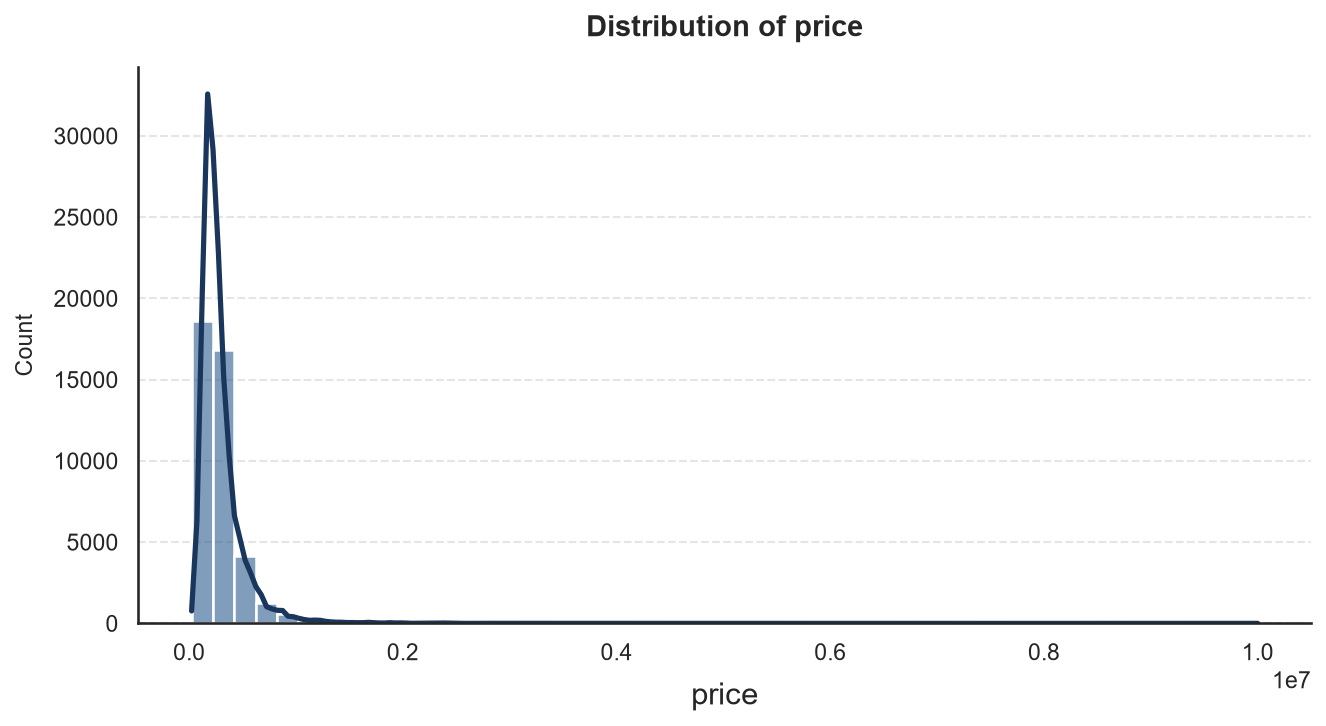

In [20]:
# target variable analysis

distribution(df["price"])

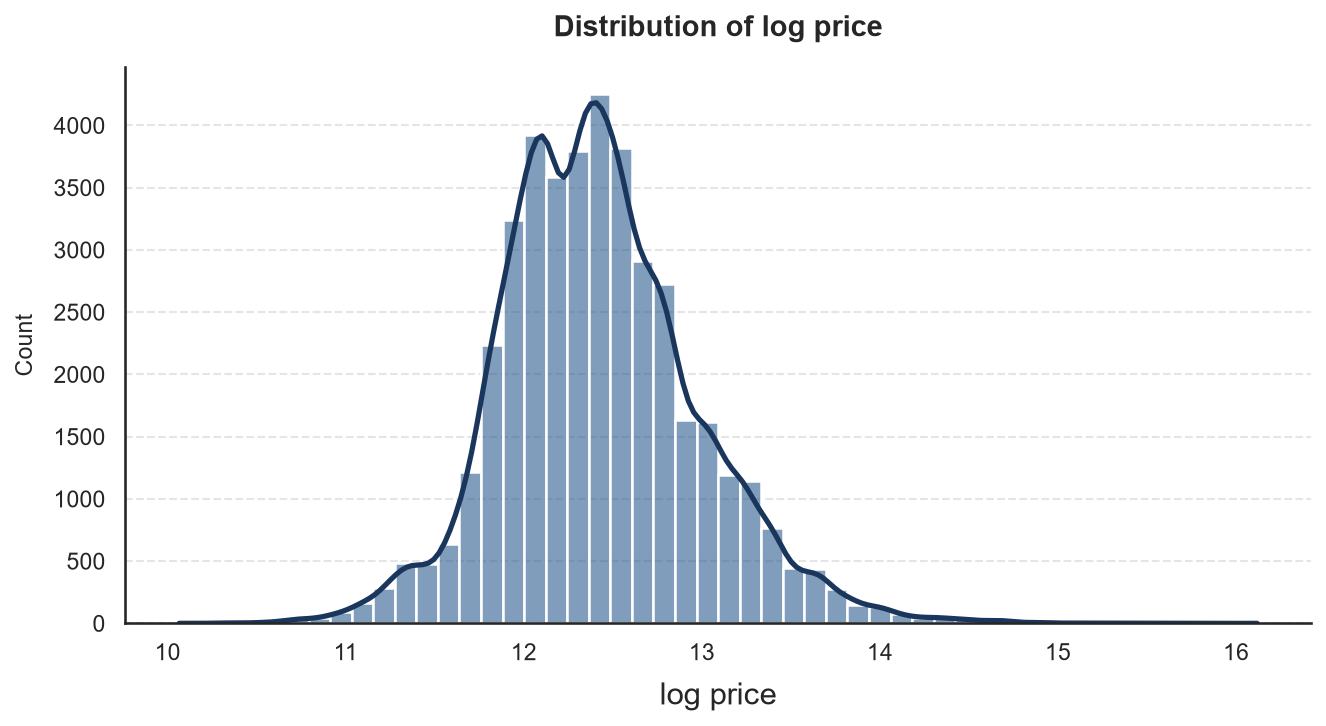

In [21]:
log_price = np.log(df["price"])
log_price.name = "log price"

distribution(log_price)

In [22]:
df["price"].skew()

np.float64(7.077170674896045)

In [23]:
# target heavily right-skewed

In [24]:
# investigating target extremes

df.sort_values("price", ascending=True)

area  location     price       id  floor  floors  hasMortgage  \
32595  80.0000000     Saray     23500  6409539      7      14         True   
32589  35.0000000   Masazır     29000  4962303      1       2        False   
32590  35.0000000   Masazır     30000  6400457      1       2        False   
32587  74.0000000     Saray     30000  6396279      9      15         True   
32597  27.0000000   Sabunçu     31500  6375628      2       2        False   
...           ...       ...       ...      ...    ...     ...          ...   
6458  772.0000000  Ağ şəhər   4200000  5116390      7      10        False   
6462  840.0000000  Ağ şəhər   5100000  6173610      8       9         True   
6461  375.6000000    Nəsimi   5300000  5471064     26      33        False   
6464  375.0000000    Nəsimi   7968750  4628501     28      33        False   
6466  150.0000000     Sahil  10000000  6376994      6       9         True   

       rooms  hasBillOfSale hasRepair                 updatedAt        lat  \
32595      3          False      True 2026-08-26 23:05:28+04:00 40.5310941   
32589      1          False     False 2026-08-25 19:35:55+04:00 40.4981367   
32590      1          False     False 2026-08-27 18:15:21+04:00 40.4978092   
32587      2           True      True 2026-08-21 23:24:11+04:00 40.5492763   
32597      1           True      True 2026-08-14 15:48:56+04:00 40.4423122   
...      ...            ...       ...                       ...        ...   
6458       8          False     False 2026-08-19 15:35:57+04:00 40.3811707   
6462       8           True     False 2026-08-08 11:14:25+04:00 40.3794299   
6461       5          False     False 2026-08-15 11:50:32+04:00 40.3743709   
6464       3          False     False 2026-08-28 12:59:35+04:00 40.3739940   
6466       5           True      True 2026-08-17 17:06:43+04:00 40.3694592   

             lng  
32595 49.7125692  
32589 49.7591400  
32590 49.7569302  
32587 49.7141911  
32597 49.9490155  
...          ...  
6458  49.8850874  
6462  49.8858853  
6461  49.8589535  
6464  49.8587206  
6466  49.8425037  

[41975 rows x 13 columns]

In [25]:
# people are setting the price as down payment and gives information about monthly payment in the description

In [26]:
df.sort_values("price", ascending=False)

area  location     price       id  floor  floors  hasMortgage  \
6466  150.0000000     Sahil  10000000  6376994      6       9         True   
6464  375.0000000    Nəsimi   7968750  4628501     28      33        False   
6461  375.6000000    Nəsimi   5300000  5471064     26      33        False   
6462  840.0000000  Ağ şəhər   5100000  6173610      8       9         True   
6458  772.0000000  Ağ şəhər   4200000  5116390      7      10        False   
...           ...       ...       ...      ...    ...     ...          ...   
32597  27.0000000   Sabunçu     31500  6375628      2       2        False   
32590  35.0000000   Masazır     30000  6400457      1       2        False   
32587  74.0000000     Saray     30000  6396279      9      15         True   
32589  35.0000000   Masazır     29000  4962303      1       2        False   
32595  80.0000000     Saray     23500  6409539      7      14         True   

       rooms  hasBillOfSale hasRepair                 updatedAt        lat  \
6466       5           True      True 2026-08-17 17:06:43+04:00 40.3694592   
6464       3          False     False 2026-08-28 12:59:35+04:00 40.3739940   
6461       5          False     False 2026-08-15 11:50:32+04:00 40.3743709   
6462       8           True     False 2026-08-08 11:14:25+04:00 40.3794299   
6458       8          False     False 2026-08-19 15:35:57+04:00 40.3811707   
...      ...            ...       ...                       ...        ...   
32597      1           True      True 2026-08-14 15:48:56+04:00 40.4423122   
32590      1          False     False 2026-08-27 18:15:21+04:00 40.4978092   
32587      2           True      True 2026-08-21 23:24:11+04:00 40.5492763   
32589      1          False     False 2026-08-25 19:35:55+04:00 40.4981367   
32595      3          False      True 2026-08-26 23:05:28+04:00 40.5310941   

             lng  
6466  49.8425037  
6464  49.8587206  
6461  49.8589535  
6462  49.8858853  
6458  49.8850874  
...          ...  
32597 49.9490155  
32590 49.7569302  
32587 49.7141911  
32589 49.7591400  
32595 49.7125692  

[41975 rows x 13 columns]

In [27]:
# high end on the other hand, looks like real listings

In [28]:
# feature analysis

location_counts = df["location"].value_counts()

location_counts

location
Həzi Aslanov          3637
Elmlər Akademiyası    2208
İnşaatçılar           2167
28 May                1973
Nəsimi                1952
                      ... 
Şüvəlan                  1
Xutor                    1
Keşlə                    1
Şimal DRES               1
Qobu                     1
Name: count, Length: 101, dtype: int64

In [29]:
rare_locations = location_counts[location_counts <= 50]

print(f"Total: {len(location_counts)} | Rare: {len(rare_locations)}")
rare_locations

Total: 101 | Rare: 50


location
Şıxov              37
Abşeron            36
Massiv D           35
Massiv V           34
Əmircan            28
M.Ə.Rəsulzadə      28
Binə               24
Buzovna            22
Günəşli            21
Mehdiabad          18
Mərdəkan           17
Ulduz              16
Zabrat             15
Ramana             13
Pirallahı          10
Qaradağ             8
Böyükşor            8
20-ci sahə          8
Yeni Ramana         8
Bülbülə             7
Bibiheybət          7
Müşfiqabad          5
1-ci mikrorayon     5
3-cü mikrorayon     5
Massiv A            5
NZS                 5
6-cı mikrorayon     5
Massiv G            4
Hökməli             4
Ceyranbatan         4
Maştağa             4
Yeni Suraxanı       4
Kubinka             3
Ələt                3
Xəzər               3
Aşağı Güzdək        3
Sulutəpə            3
Görədil             2
Massiv B            2
2-ci Alatava        2
Dədə Qorqud         2
Çiçək               1
Qobustan            1
Qala                1
Xocəsən             1
Şüvəlan             1
Xutor               1
Keşlə               1
Şimal DRES          1
Qobu                1
Name: count, dtype: int64

In [30]:
# half of the locations have less than 50 listings

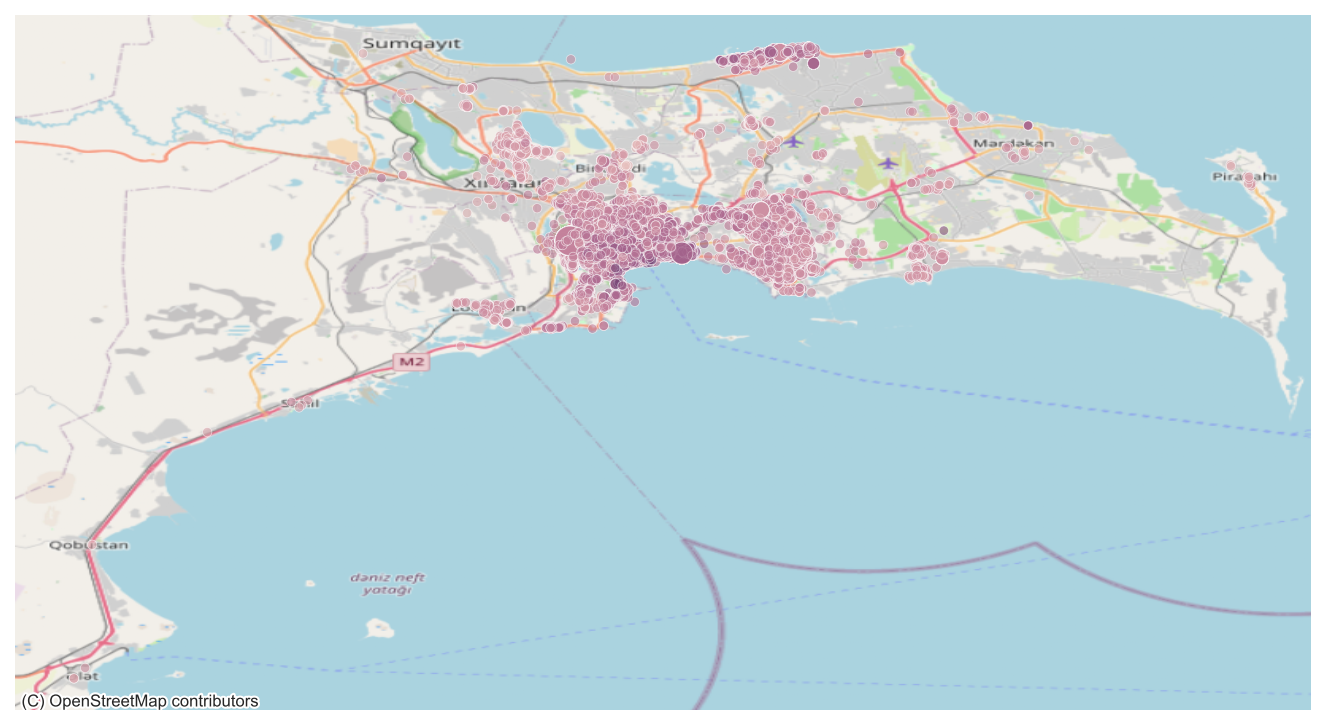

In [31]:
mapplot(df)

In [32]:
df.value_counts(["lat", "lng"])

lat         lng       
40.3940000  49.7950000    225
40.3813596  49.8843435    114
40.3798280  49.8087820     99
40.4209144  49.8427795     96
40.4089166  49.8639996     68
                         ... 
40.3775704  49.8370401      1
40.4167743  49.9465860      1
40.3864577  49.9601552      1
40.3826577  49.9843281      1
40.4038482  49.8635751      1
Name: count, Length: 40212, dtype: int64

In [33]:
check_location_of_coordinates(df, 40.39400000, 49.79500000)

location
İnşaatçılar    225
Name: count, dtype: int64

In [34]:
check_location_of_coordinates(df, 40.3813596, 49.8843435)

location
Ağ şəhər    114
Name: count, dtype: int64

In [35]:
check_location_of_coordinates(df, 40.3798280, 49.8087820)

location
Elmlər Akademiyası    90
Yasamal                9
Name: count, dtype: int64

In [36]:
# Locations have default coordinates set to them. Probably used when the seller doesn't specify a coordinate.

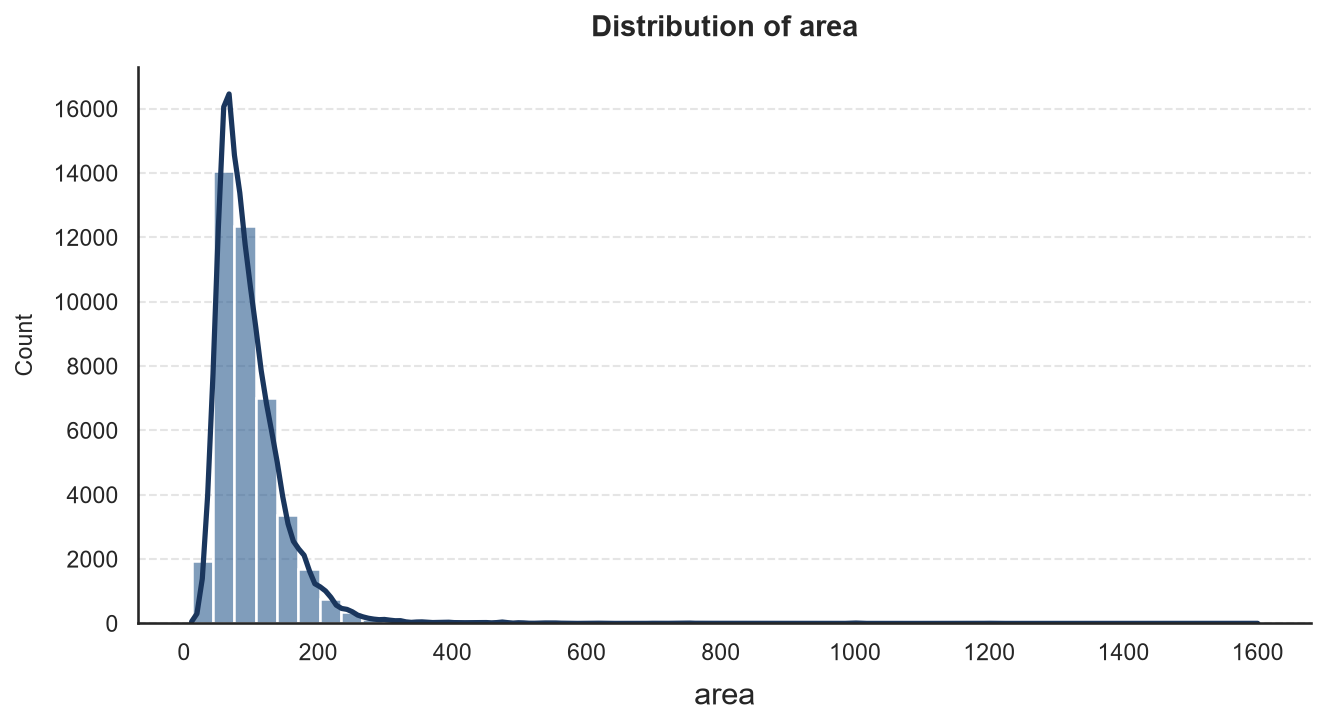

In [37]:
distribution(df["area"])

In [38]:
df["area"].skew()

np.float64(4.511855600625263)

In [39]:
df.nlargest(20, "area")

area            location    price       id  floor  floors  \
6437  1600.0000000   Şah İsmayıl Xətai  2700000  5892274     28      28   
6153  1300.0000000   Şah İsmayıl Xətai  1300000  5778758     20      21   
32362 1300.0000000        Həzi Aslanov   460000  6271576     12      12   
6430  1200.0000000   Şah İsmayıl Xətai  2490000  2677642     25      28   
6431  1200.0000000   Şah İsmayıl Xətai  2490000  6381263     25      28   
6164  1000.0000000   Şah İsmayıl Xətai  1300000  6259942     20      21   
6158  1000.0000000   Şah İsmayıl Xətai  1300000  6098956     16      17   
6268  1000.0000000              28 May  1500000  6404577     15      16   
6165  1000.0000000   Şah İsmayıl Xətai  1300000  6260006     20      22   
6174  1000.0000000   Şah İsmayıl Xətai  1300000  6276969     20      22   
6260  1000.0000000              28 May  1500000  6387123     15      16   
6441   872.0000000              Nizami  2850000  4779165     15      16   
6462   840.0000000            Ağ şəhər  5100000  6173610      8       9   
5665   800.0000000              28 May   950000  6370424     22      22   
6139   790.0000000   Nəriman Nərimanov  1260000  6367074      9       9   
5164   780.0000000  Elmlər Akademiyası   840000  6178755     16      17   
6458   772.0000000            Ağ şəhər  4200000  5116390      7      10   
16746  756.0000000             Əhmədli   187000  6340630      6       9   
6315   755.0000000            Ağ şəhər  1700000  5711656      8       8   
6314   750.0000000            Ağ şəhər  1700000  5574203      8       8   

       hasMortgage  rooms  hasBillOfSale hasRepair                 updatedAt  \
6437         False     20           True      True 2026-08-14 15:40:19+04:00   
6153         False     10           True     False 2026-08-17 17:44:03+04:00   
32362        False      8           True      True 2026-08-08 12:41:29+04:00   
6430         False     10           True     False 2026-08-02 17:58:26+04:00   
6431          True      8           True     False 2026-08-16 17:19:09+04:00   
6164          True     10           True     False 2026-08-28 18:07:52+04:00   
6158         False     10           True     False 2026-08-22 07:46:26+04:00   
6268         False     10           True      True 2026-08-25 19:23:51+04:00   
6165         False     10           True     False 2026-08-28 18:34:28+04:00   
6174         False     10           True     False 2026-08-07 10:06:51+04:00   
6260          True     10           True      True 2026-08-18 17:56:45+04:00   
6441         False      7           True     False 2026-08-10 12:02:11+04:00   
6462          True      8           True     False 2026-08-08 11:14:25+04:00   
5665          True      5           True      True 2026-08-28 10:36:08+04:00   
6139         False      8           True      True 2026-08-11 15:48:49+04:00   
5164          True      8           True     False 2026-08-11 09:47:15+04:00   
6458         False      8          False     False 2026-08-19 15:35:57+04:00   
16746        False      3           True      True 2026-08-04 10:13:49+04:00   
6315         False      7          False     False 2026-08-28 15:35:13+04:00   
6314         False      8          False     False 2026-08-18 10:37:04+04:00   

             lat        lng  
6437  40.3780635 49.8749456  
6153  40.3855817 49.8670209  
32362 40.3776579 49.9539136  
6430  40.3843596 49.8738100  
6431  40.3777887 49.8741724  
6164  40.3838256 49.8706435  
6158  40.3855037 49.8666667  
6268  40.3853178 49.8399609  
6165  40.3851784 49.8666840  
6174  40.3851876 49.8666180  
6260  40.3855429 49.8401372  
6441  40.3878228 49.8313812  
6462  40.3794299 49.8858853  
5665  40.3817866 49.8433420  
6139  40.3991090 49.8751074  
5164  40.3691280 49.8166531  
6458  40.3811707 49.8850874  
16746 40.3856749 49.9526292  
6315  40.3818794 49.8877767  
6314  40.3815259 49.8868480

In [40]:
df["unit_price"] = df["price"] / df["area"]

df.nsmallest(20, "unit_price")

area      location   price       id  floor  floors  hasMortgage  \
16746  756.0000000       Əhmədli  187000  6340630      6       9        False   
32595   80.0000000         Saray   23500  6409539      7      14         True   
32362 1300.0000000  Həzi Aslanov  460000  6271576     12      12        False   
32587   74.0000000         Saray   30000  6396279      9      15         True   
32656  110.0000000      Binəqədi   49000  6345191      1       1        False   
32636  100.0000000       Hökməli   45000  6364815      2       2        False   
32780  120.0000000          Qala   59500  6373554      1       1        False   
32609   73.0000000      Biləcəri   39999  6172471      1       2         True   
32900  110.0000000     Neftçilər   65000  6378997      1      10        False   
32801  100.0000000       Abşeron   60000  6372155      8       9        False   
32911  107.4000000      Dərnəgül   65000  6402561     14      14         True   
32611   60.0000000      Binəqədi   40000  5966382      2       4        False   
32961  100.0000000       Masazır   67500  6304905      6       6        False   
32966  100.0000000       Masazır   68000  6075154      6       6        False   
33154  110.0000000       Masazır   75000  5926442      6       6        False   
32756   83.0000000       Masazır   58000  5351145      6       6        False   
8224   213.0000000       Masazır  150000  6285074      9       9         True   
32600   50.0000000       Sabunçu   36000  6340312      1       2        False   
32848   87.2000000     Nərimanov   63000  6363201      1       1        False   
32782   83.0000000       Masazır   60000  5071285      6       6        False   

       rooms  hasBillOfSale hasRepair                 updatedAt        lat  \
16746      3           True      True 2026-08-04 10:13:49+04:00 40.3856749   
32595      3          False      True 2026-08-26 23:05:28+04:00 40.5310941   
32362      8           True      True 2026-08-08 12:41:29+04:00 40.3776579   
32587      2           True      True 2026-08-21 23:24:11+04:00 40.5492763   
32656      4          False      True 2026-08-03 17:51:47+04:00 40.4764203   
32636      4          False      True 2026-08-10 18:27:55+04:00 40.4224165   
32780      5          False      True 2026-08-25 21:51:06+04:00 40.4404327   
32609      3          False      True 2026-08-28 08:46:08+04:00 40.4403340   
32900      2           True      True 2026-08-19 12:34:39+04:00 40.4107382   
32801      3           True      True 2026-08-13 11:51:40+04:00 40.5859848   
32911      3           True      True 2026-08-24 16:48:28+04:00 40.4229576   
32611      2          False     False 2026-08-25 13:14:53+04:00 40.4692055   
32961      3           True     False 2026-08-24 11:16:40+04:00 40.4910862   
32966      3           True     False 2026-08-20 23:03:39+04:00 40.4909557   
33154      4          False     False 2026-08-08 17:49:43+04:00 40.4892367   
32756      2          False     False 2026-08-16 22:04:10+04:00 40.4912168   
8224       3           True      True 2026-08-11 13:26:46+04:00 40.4911494   
32600      2          False      True 2026-08-01 19:02:06+04:00 40.4494629   
32848      3          False      True 2026-08-20 13:38:59+04:00 40.3981257   
32782      2          False     False 2026-08-11 12:15:58+04:00 40.4921970   

             lng  unit_price  
16746 49.9526292 247.3544974  
32595 49.7125692 293.7500000  
32362 49.9539136 353.8461538  
32587 49.7141911 405.4054054  
32656 49.8202876 445.4545455  
32636 49.7130374 450.0000000  
32780 50.1614221 495.8333333  
32609 49.8056617 547.9315068  
32900 49.9384708 590.9090909  
32801 49.6299635 600.0000000  
32911 49.8563788 605.2141527  
32611 49.8409192 666.6666667  
32961 49.7538403 675.0000000  
32966 49.7551277 680.0000000  
33154 49.7538403 681.8181818  
32756 49.7530678 698.7951807  
8224  49.7489559 704.2253521  
32600 49.9468264 720.0000000  
32848 49.9049462 722.4770642  
32782 49.7532177 722.8915663

In [41]:
df = df.drop(columns=["unit_price"])

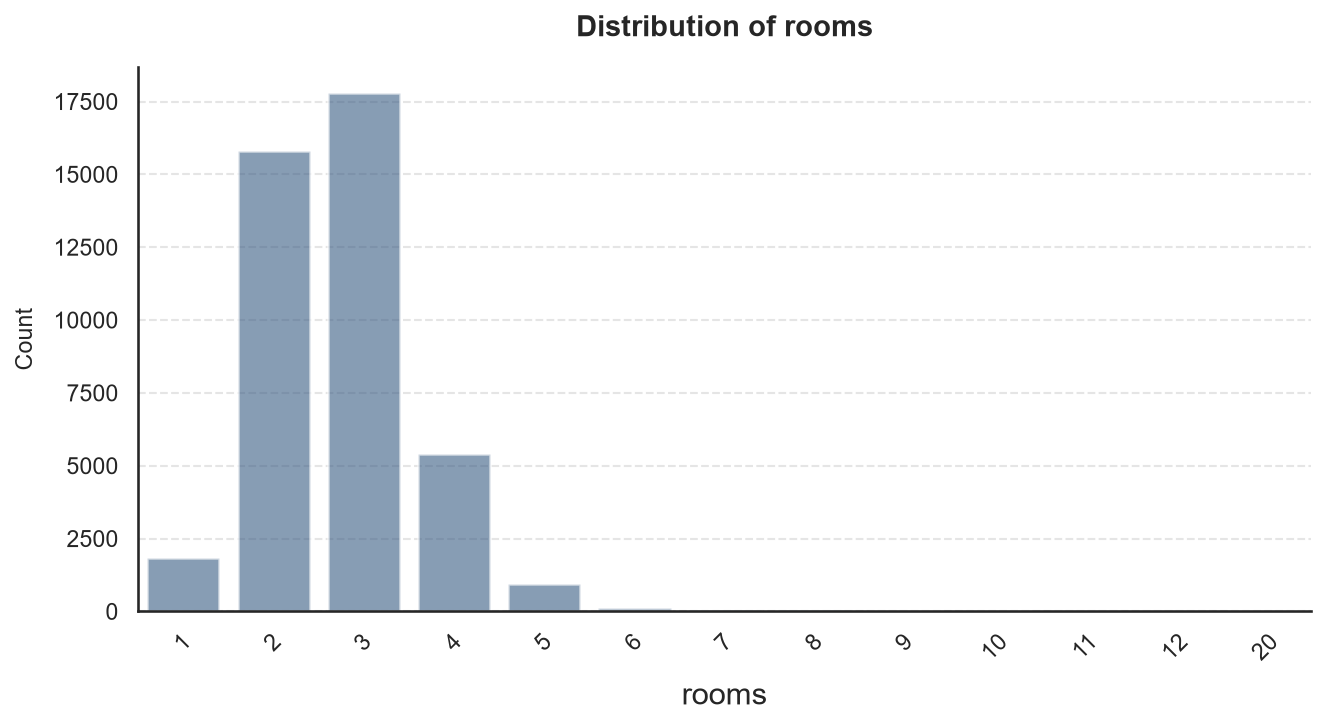

In [42]:
barplot(df["rooms"])

In [43]:
df["rooms"].value_counts()

rooms
3     17779
2     15804
4      5387
1      1831
5       932
6       133
7        52
8        38
10       11
9         3
12        2
11        2
20        1
Name: count, dtype: int64

In [44]:
df["rooms"].skew()

np.float64(1.127188026396702)

In [45]:
# I think grouping 7+ room count can be reasonable

In [46]:
# Bivariate analysis

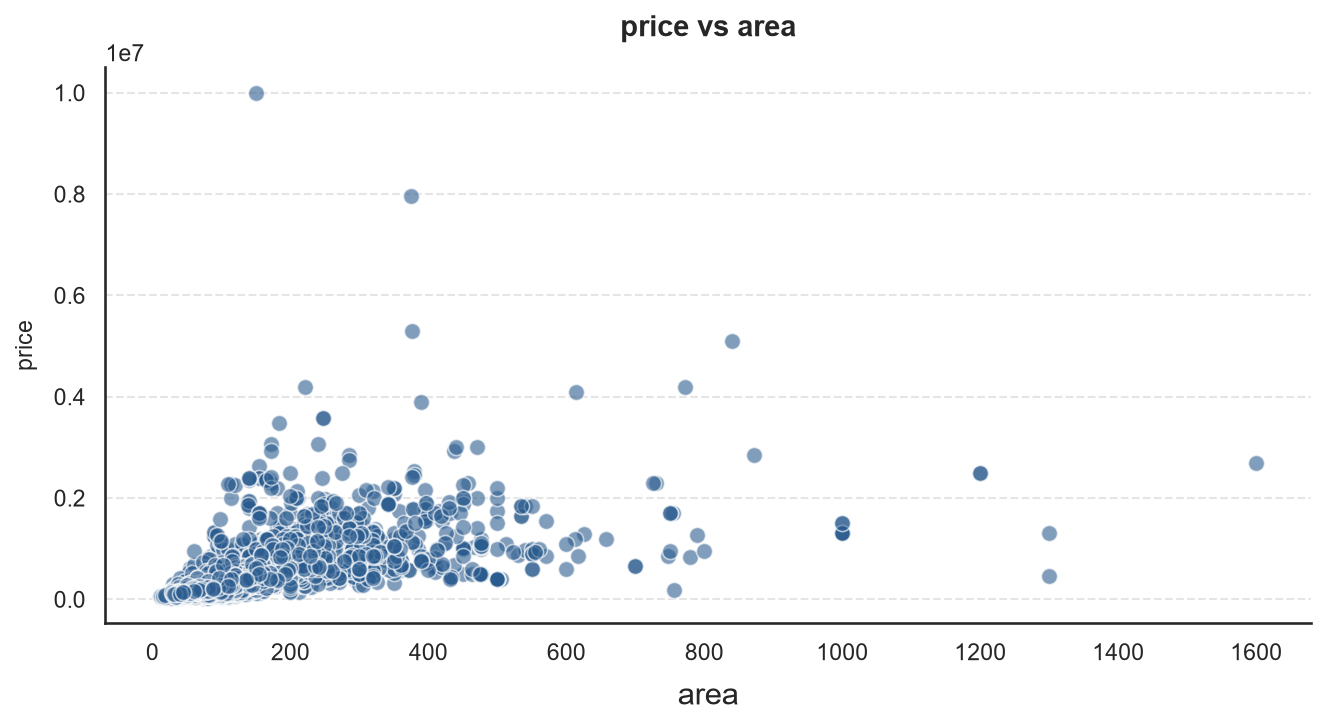

In [47]:
scatterplot(df["area"], df["price"])

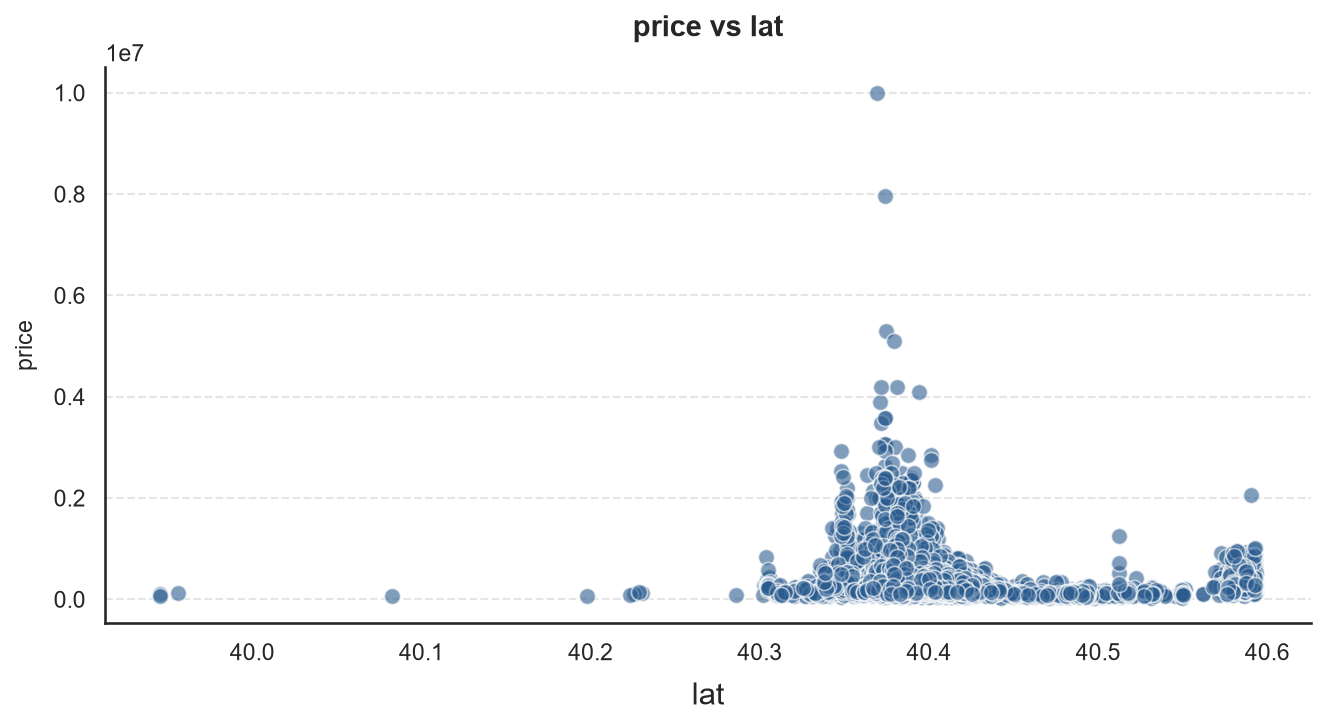

In [48]:
scatterplot(df["lat"], df["price"])

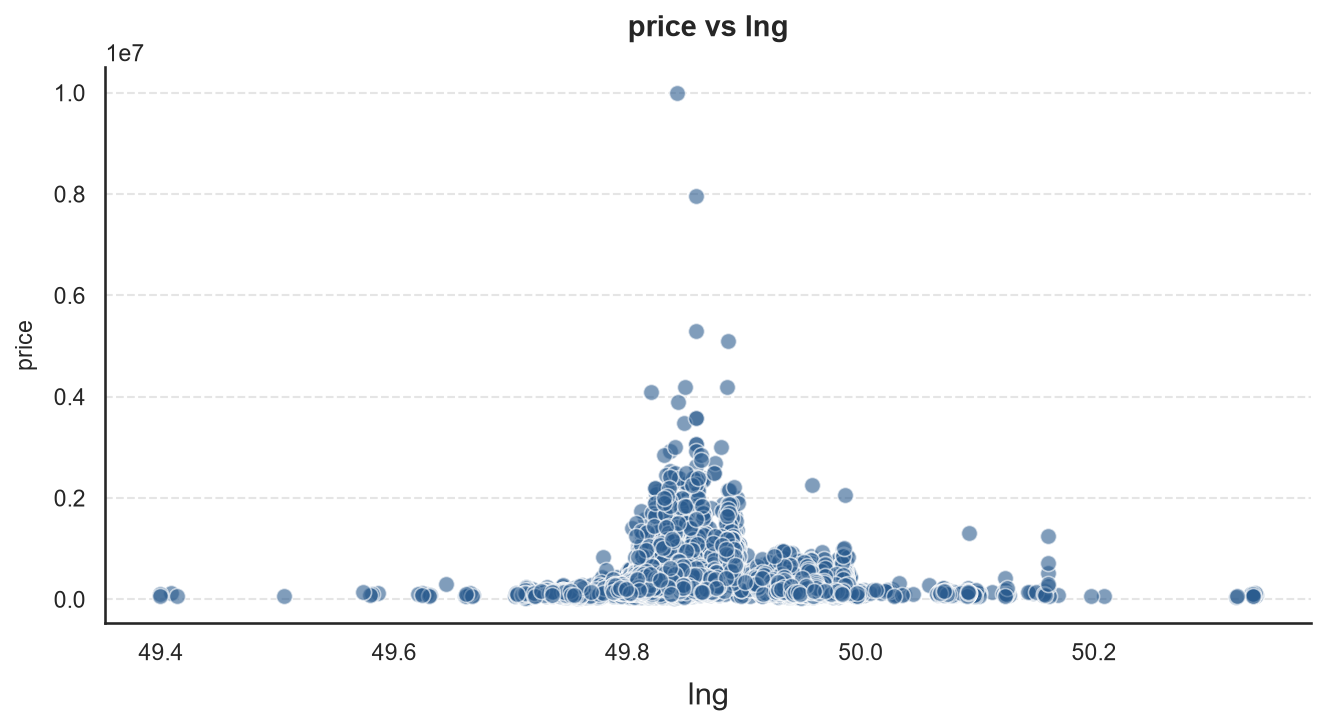

In [49]:
scatterplot(df["lng"], df["price"])

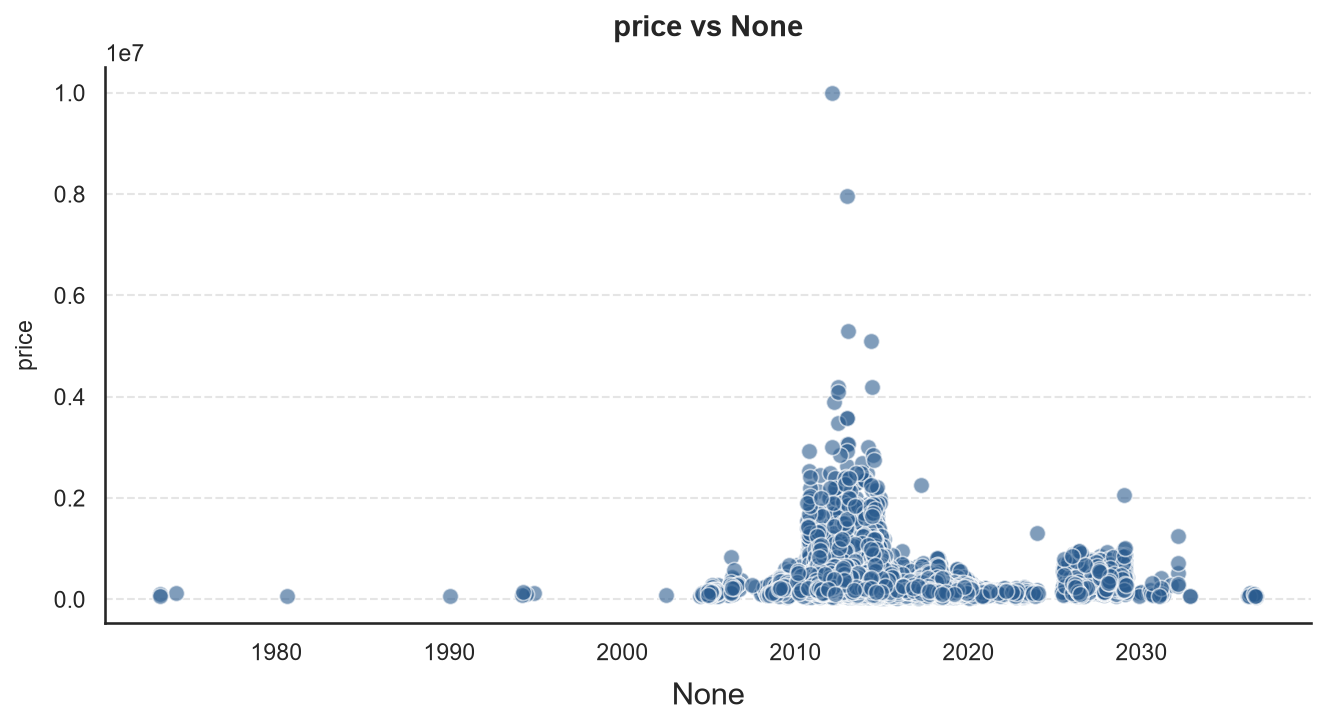

In [50]:
scatterplot((df["lng"] * df["lat"]), df["price"])

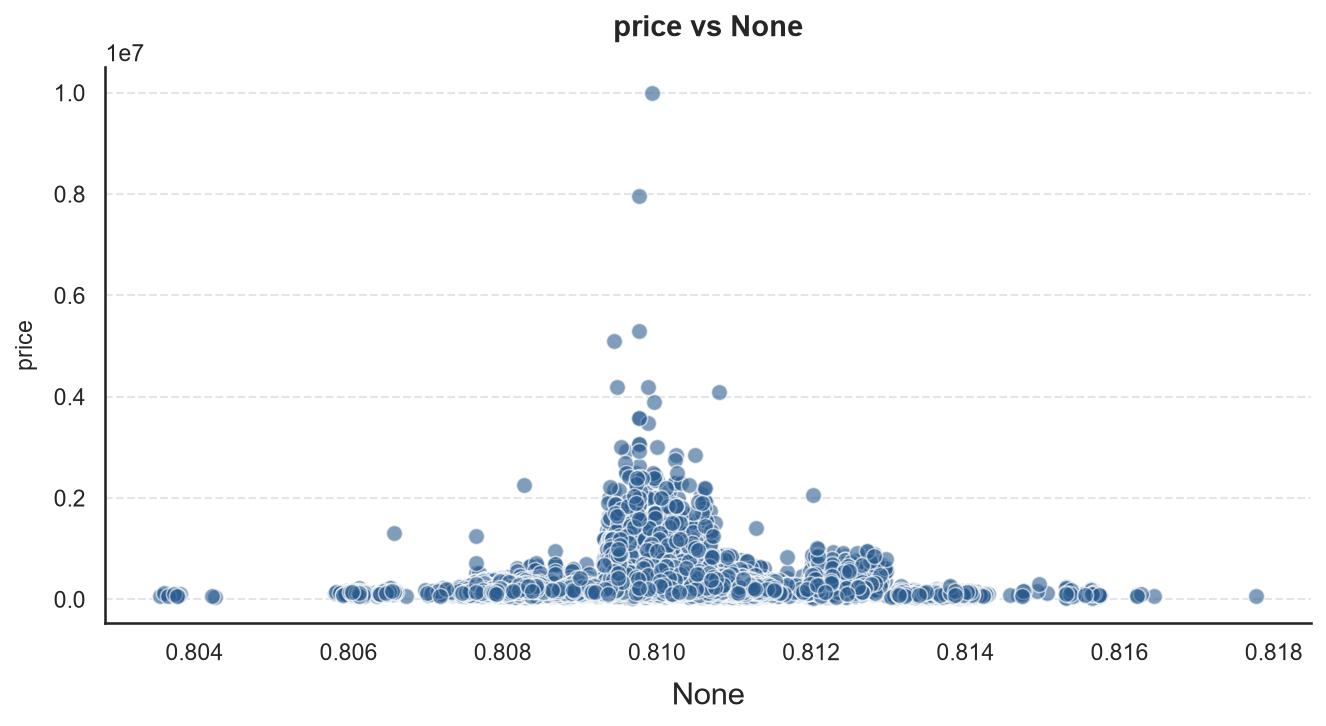

In [51]:
scatterplot((df["lat"] / df["lng"]), df["price"])

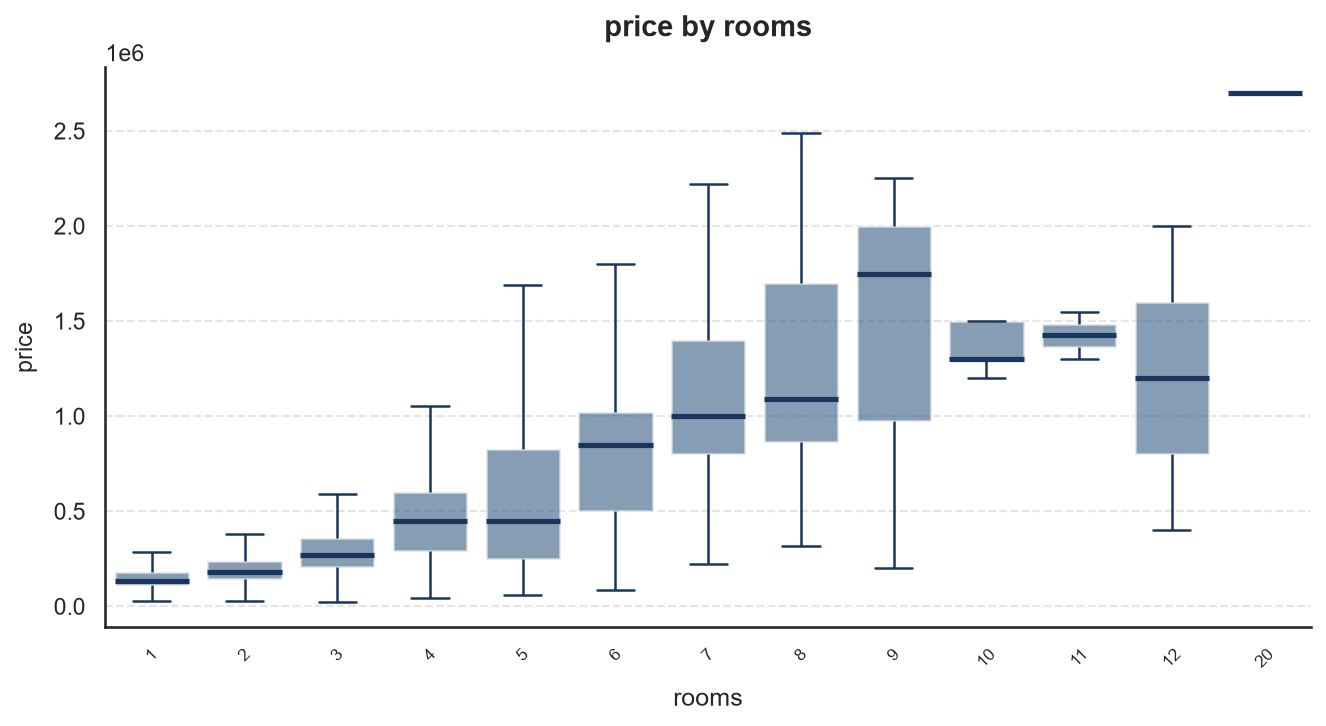

In [52]:
boxplot(df["rooms"], df["price"])

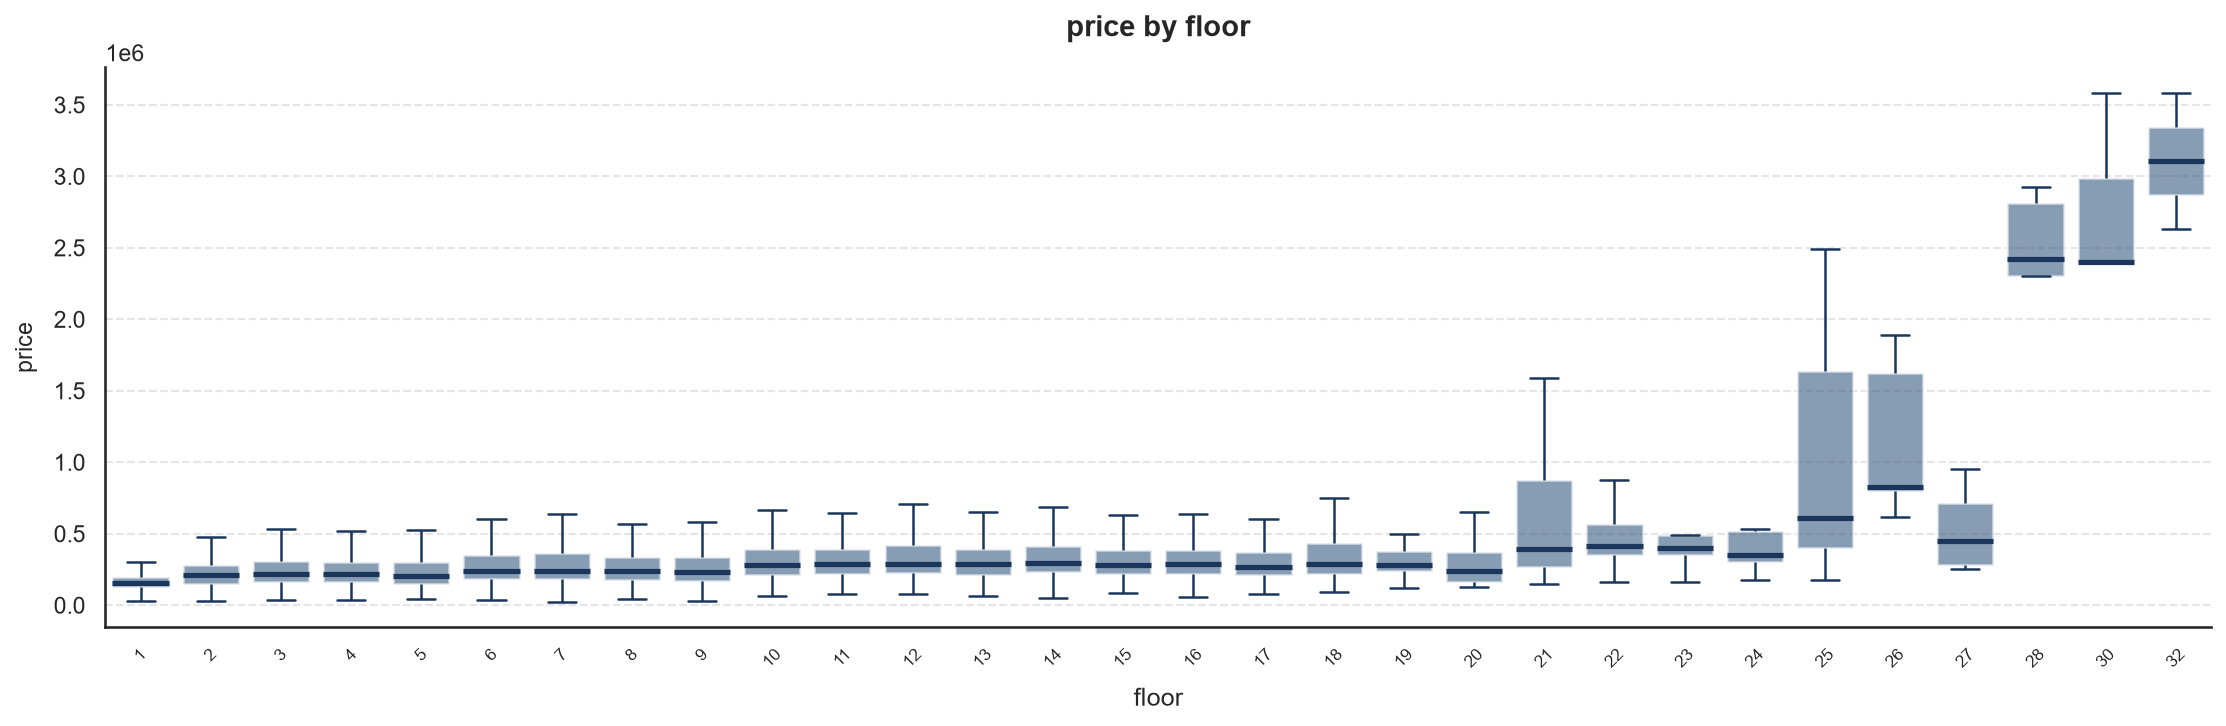

In [53]:
boxplot(df["floor"], df["price"])

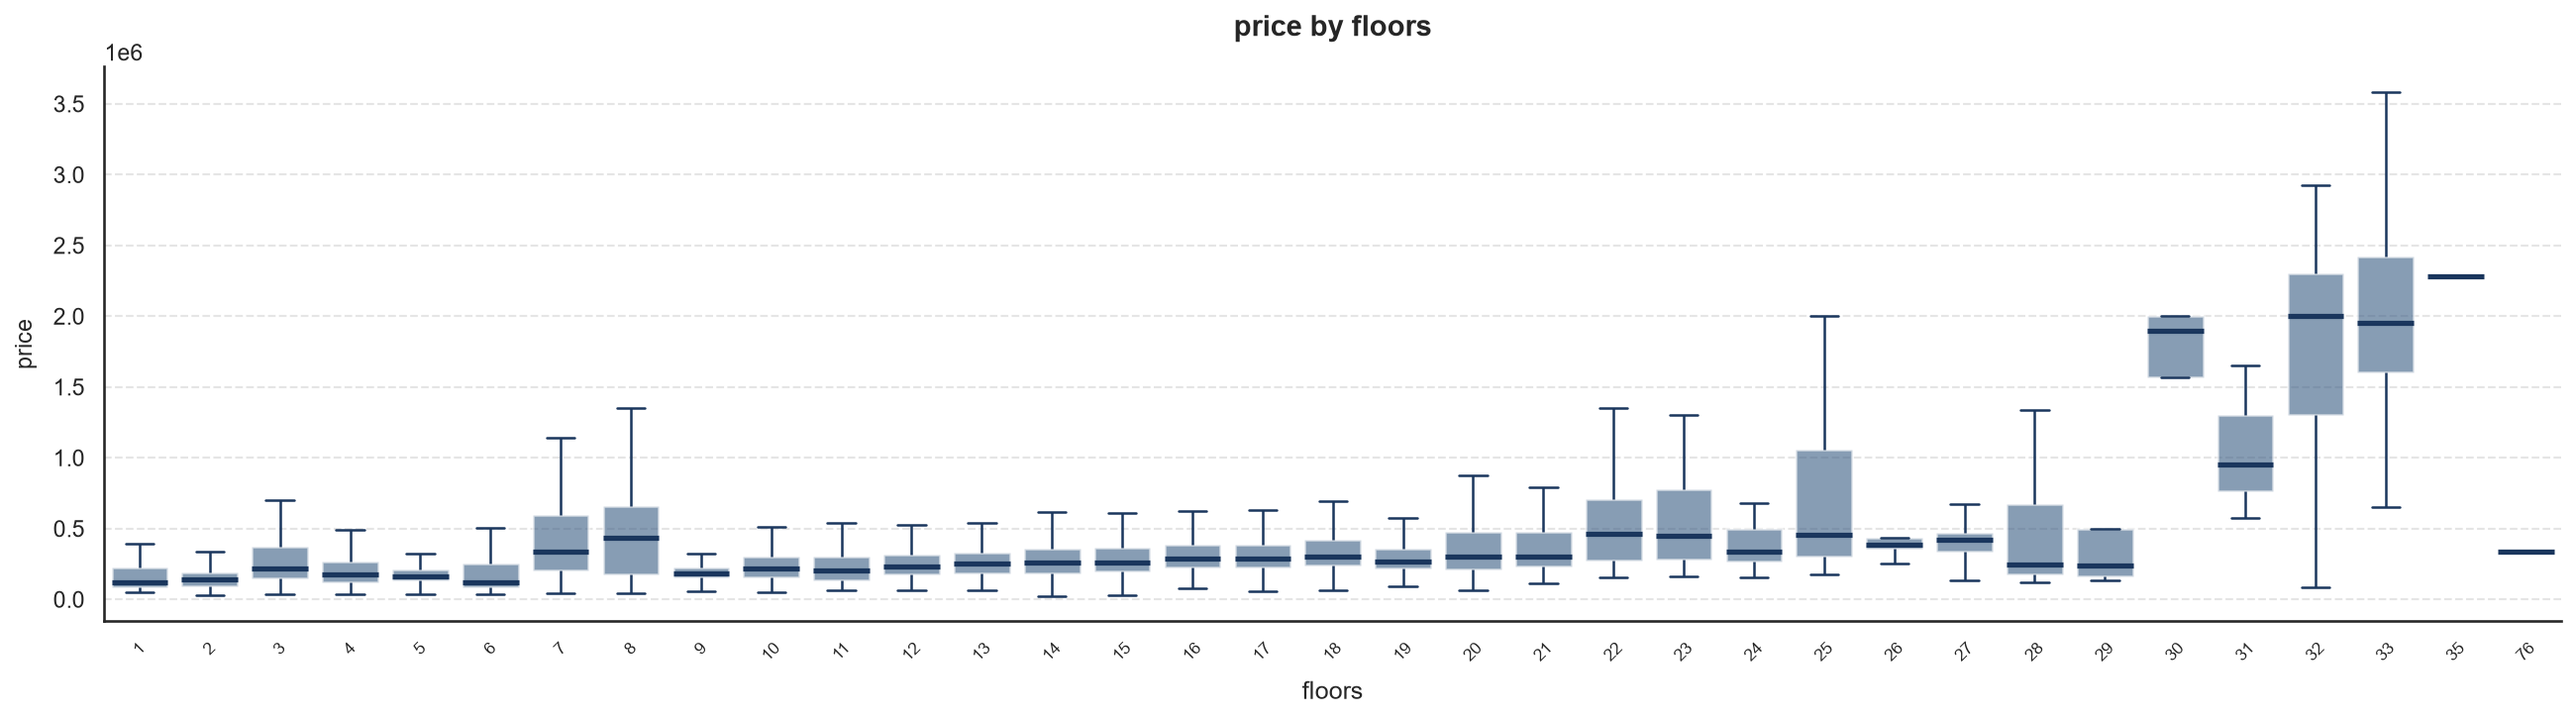

In [54]:
boxplot(df["floors"], df["price"])

In [55]:
# floor and floors doesn't catch an relationship by themselves. Can make them useful with engineering domain features like if floor == 1 or floor ==floors

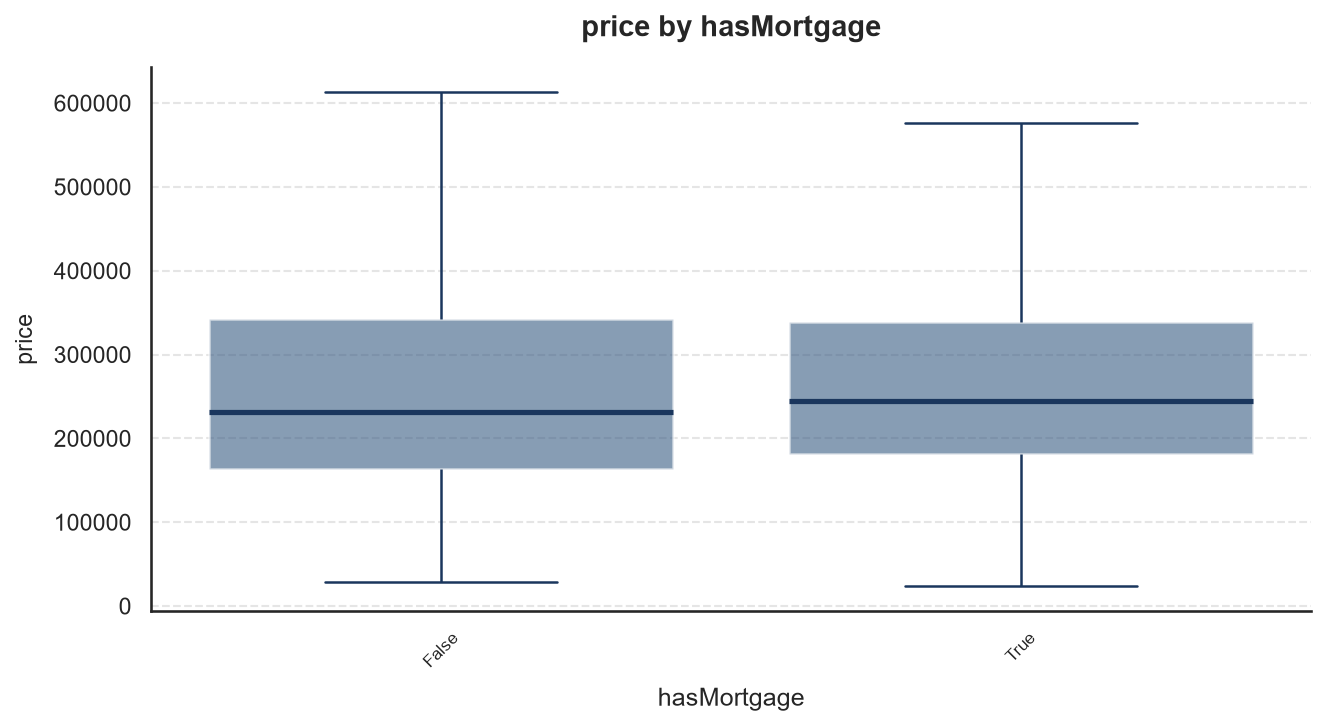

In [56]:
boxplot(df["hasMortgage"], df["price"])

In [57]:
# Doesn't have an affect on the target

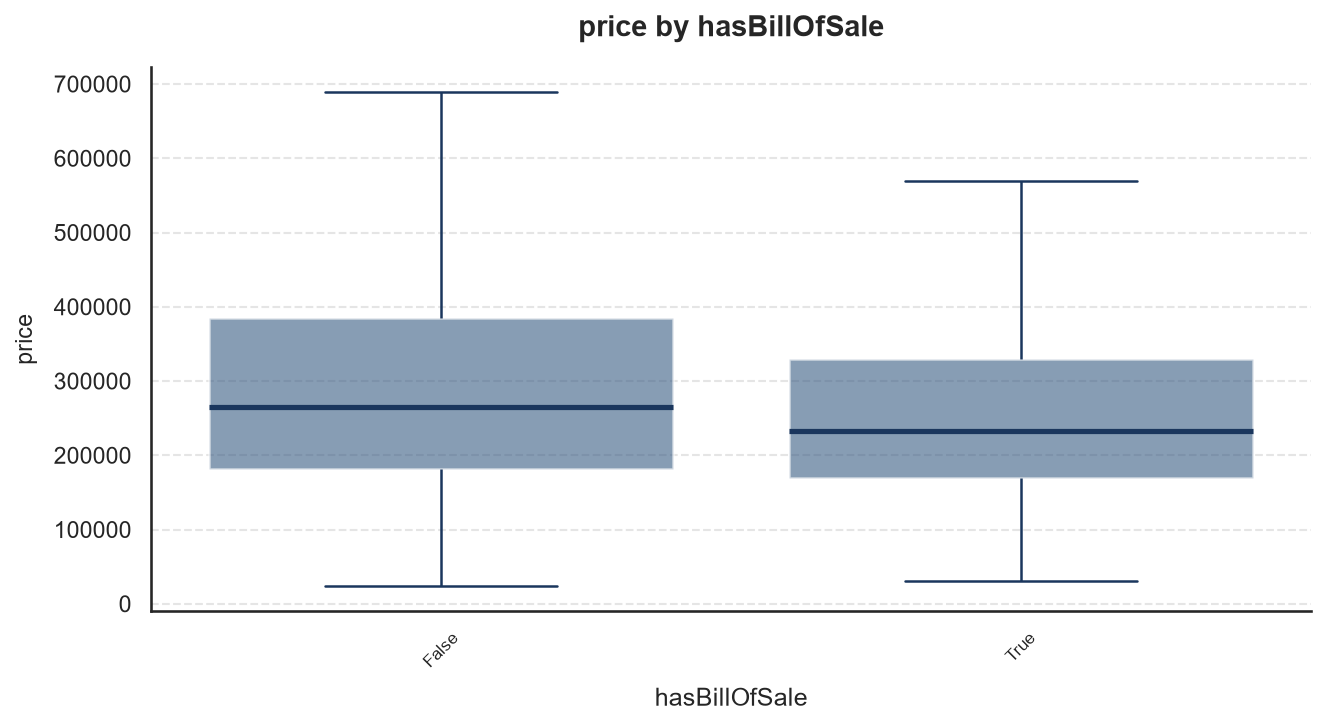

In [58]:
boxplot(df["hasBillOfSale"], df["price"])

In [59]:
df["hasBillOfSale"].value_counts()

hasBillOfSale
True     34232
False     7743
Name: count, dtype: int64

In [60]:
# Would expect the opposite.

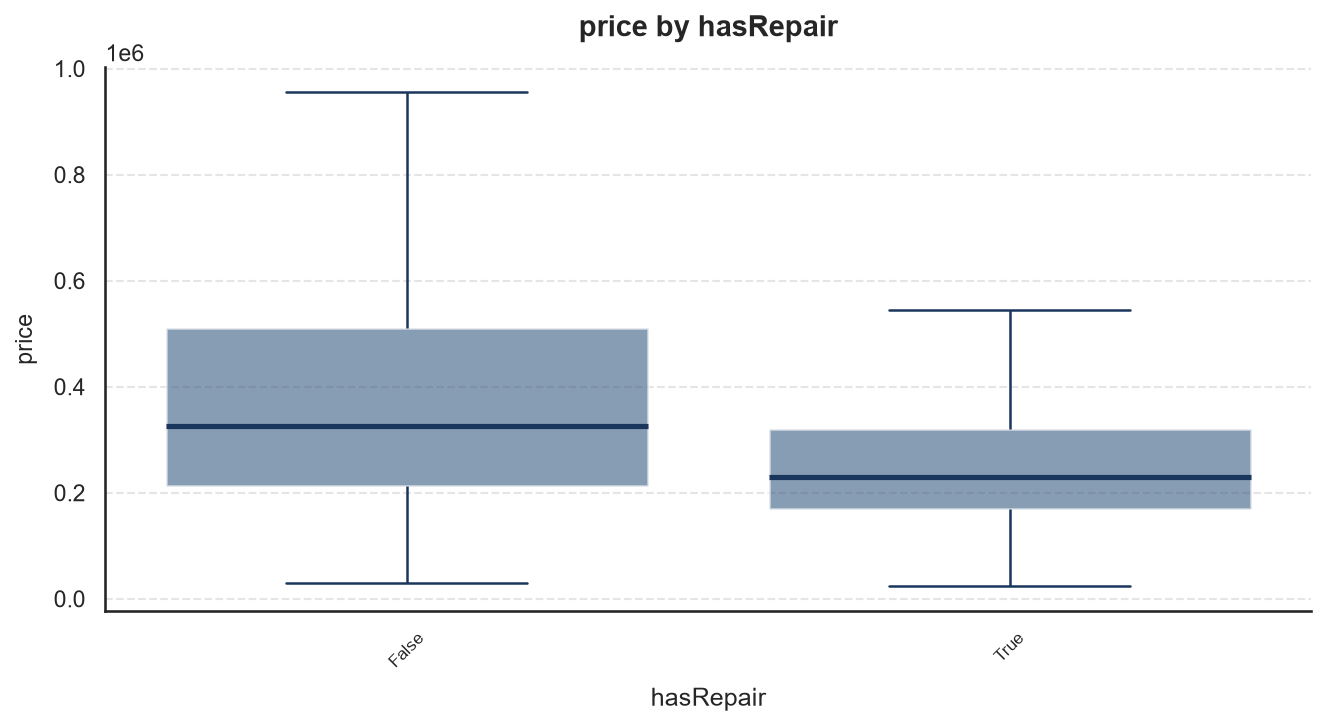

In [61]:
boxplot(df["hasRepair"], df["price"])

In [62]:
df["hasRepair"].value_counts()

hasRepair
True     35938
False     5881
Name: count, dtype: int64

In [63]:
# I think this makes sense as no repair appears on newer and luxury listings. The older apartments have Repair even if it is in a bad state, and have people living inside.

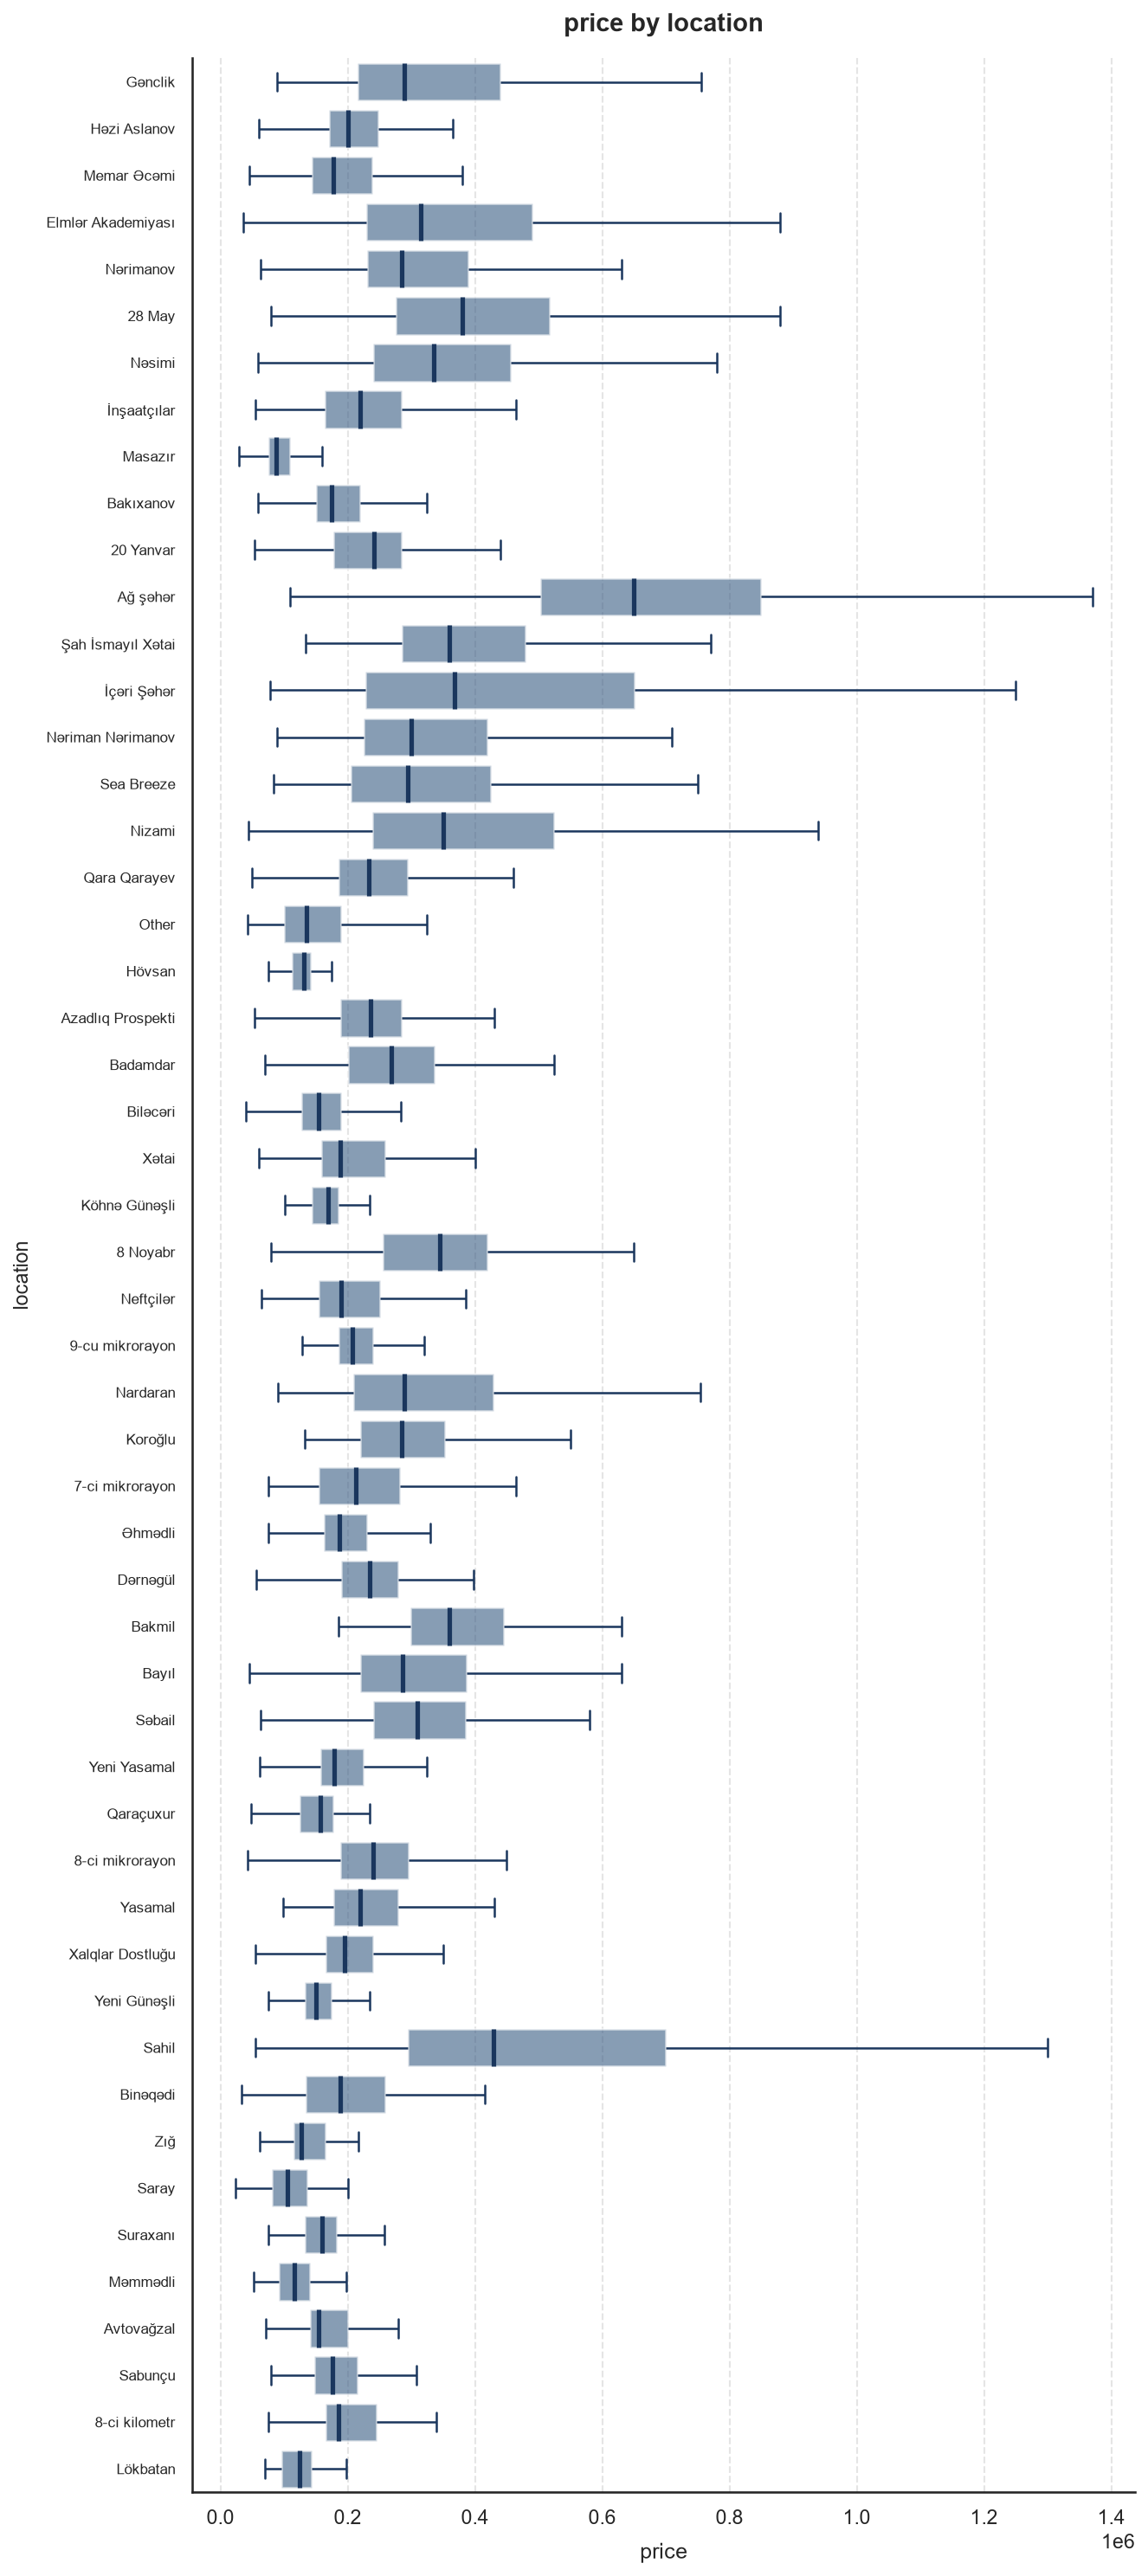

In [64]:
location_treshold = 50
counts = df["location"].value_counts()
rare_locations = counts[counts < location_treshold].index
location_filtered = df["location"].replace(rare_locations, "Other")

boxplot(location_filtered, df["price"], "horizontal")

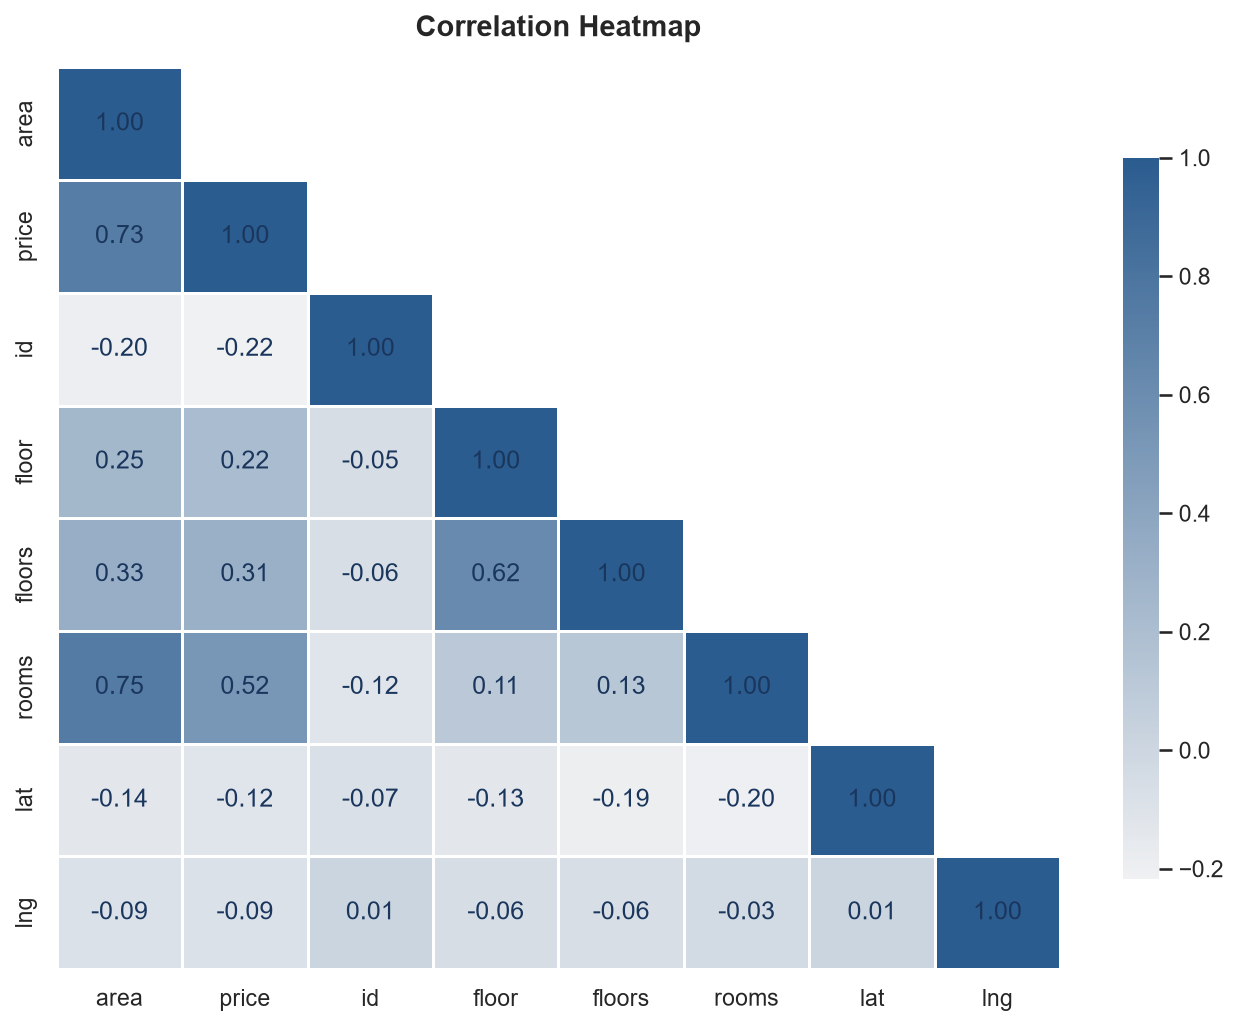

In [65]:
heatmap(df)

In [66]:
"""
FINDINGS

There is no physically impossible values, dates are in reasonable range.

Only "hasRepair" column has missing values. It is not tied to value itself, and only 0.38% of the data is missing, so can be dropped or imputed using simple functions,
I dont think it would make any difference.

* There is no direct duplicates in the data, because each row has unique id (and updatedAt value). When ignored these, there are some apartments that is listed twice or even more.
When ignored other fields like price to check for same apartment listed with different prices, there are some listings like these but much more part of it identical but different
apartments, and I don't know any way to filter them. 

* Target variable is highly skewed. Must perform log transformation, check if anythink else needs to be decided based on that.

* Listers are setting downpayment as the price and gives information about monthly payment in description. There is no easy way to filter these out either. 

* Almost half of the location values have less than 50 listings. I think grouping these under "Other" is a good choice.
Locations have default coordinate values set to them, when listers doesn't specify a coordinate these are used instead. 

* To filter out misinputs and downpayments use unit_price < 450

Room counts are not balanced too. Maybe group 7+ ones together?

Floor and Floors is not strong signal by themselves, but can be engineered to new domain features, like if floor == 1 or floor == floors (these are usually cheaper)

hasMortgage does not have any signal
* hasBillOfSale has opposite of what would I expected
hasRepair can be one of the strongest features

* location and lat/lng values both can be strong signal, I need to decide whether engineer new features using lat/lng values, drop either location or coordinates.

""";